In [1]:
import os

# Fix: TensorFlow/Protobuf crash ('MessageFactory' has no attribute 'GetPrototype').
# Must be set BEFORE importing tensorflow/protobuf-dependent modules.
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import sys
import random
import numpy as np
import pandas as pd
import cv2

from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Import protobuf early to lock the pure-Python implementation, then TF.
import google.protobuf  # noqa: F401
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)



2026-01-09 21:09:04.997372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767992945.015171      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767992945.020025      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF version: 2.18.0


In [2]:
BASE_PATH = "/kaggle/input/aptos2019-blindness-detection"
if not os.path.exists(BASE_PATH):
    alt = "/kaggle/data/aptos2019-blindness-detection"
    if os.path.exists(alt):
        BASE_PATH = alt
    else:
        alt2 = "/kaggle/input"
        if os.path.exists(os.path.join(alt2, "aptos2019-blindness-detection")):
            BASE_PATH = os.path.join(alt2, "aptos2019-blindness-detection")
        alt3 = "/kaggle/data"
        if (not os.path.exists(BASE_PATH)) and os.path.exists(
            os.path.join(alt3, "aptos2019-blindness-detection")
        ):
            BASE_PATH = os.path.join(alt3, "aptos2019-blindness-detection")

train_img_path = os.path.join(BASE_PATH, "train_images")
test_img_path = os.path.join(BASE_PATH, "test_images")
train_label_path = os.path.join(BASE_PATH, "train.csv")
test_label_path = os.path.join(BASE_PATH, "test.csv")

if not os.path.exists(train_img_path):
    raise FileNotFoundError(f"train_images folder not found: {train_img_path}")
if not os.path.exists(test_img_path):
    raise FileNotFoundError(f"test_images folder not found: {test_img_path}")
if not os.path.exists(train_label_path):
    raise FileNotFoundError(f"train.csv not found: {train_label_path}")
if not os.path.exists(test_label_path):
    raise FileNotFoundError(f"test.csv not found: {test_label_path}")

df_train = pd.read_csv(train_label_path)
df_test = pd.read_csv(test_label_path)

print("BASE_PATH:", BASE_PATH)
print("num of train images ", len(os.listdir(train_img_path)))
print("num of test images ", len(os.listdir(test_img_path)))
print(df_train.head())
print(df_test.head())



BASE_PATH: /kaggle/input/aptos2019-blindness-detection
num of train images  3296
num of test images  368
        id_code  diagnosis
0  2a2274bcb00a          0
1  eda29a9d78f3          0
2  789c60cba801          0
3  a07efb1ecfc0          0
4  44855f666225          2
        id_code
0  b460ca9fa26f
1  6cee2e148520
2  ca6842bfcbc9
3  6cbc3dad809c
4  a9bc2f892cb3


In [3]:
pass



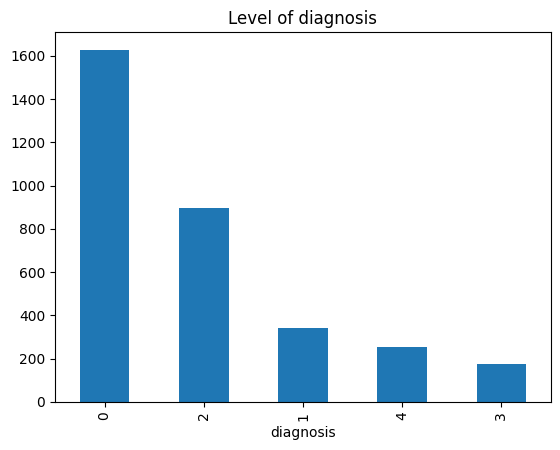

In [4]:
import matplotlib.pyplot as plt

df_train["diagnosis"].value_counts().plot(kind="bar")
plt.title("Level of diagnosis")
plt.show()



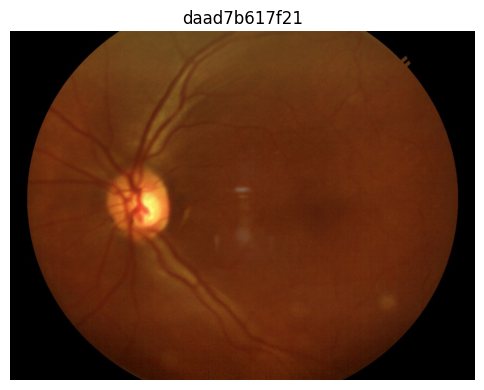

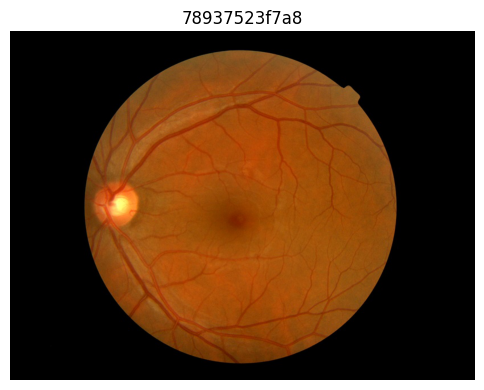

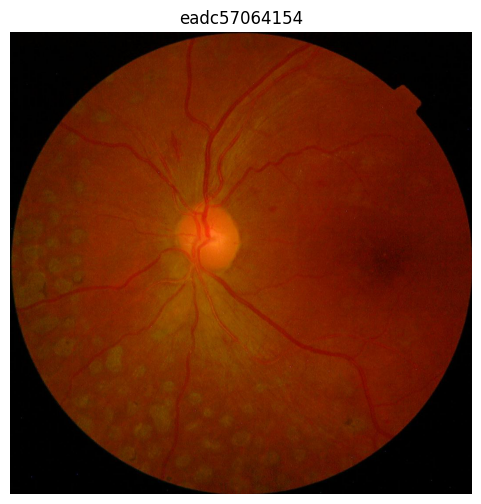

In [5]:
samp = random.sample(df_train["id_code"].tolist(), 3)
for i, sid in enumerate(samp, 1):
    plt.figure(figsize=(6, 6))
    file_path = os.path.join(train_img_path, f"{sid}.png")
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.title(sid)
    plt.show()



In [6]:
pass



In [7]:
df_train_img = []
train_list = df_train["id_code"].tolist()

for item in tqdm(train_list, desc="Loading train images"):
    file_path = os.path.join(train_img_path, f"{item}.png")
    img = cv2.imread(file_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {file_path}")
    img = cv2.resize(img, (150, 150), interpolation=cv2.INTER_AREA)
    df_train_img.append(img)

df_train_img = np.array(df_train_img, np.float32) / 255.0
print(
    "Train tensor:",
    df_train_img.shape,
    df_train_img.dtype,
    df_train_img.min(),
    df_train_img.max(),
)



Loading train images: 100%|██████████| 3295/3295 [05:24<00:00, 10.16it/s]


Train tensor: (3295, 150, 150, 3) float32 0.0 1.0


In [8]:
df_test_img = []
for item in tqdm(df_test["id_code"].tolist(), desc="Loading test images"):
    file_path = os.path.join(test_img_path, f"{item}.png")
    img = cv2.imread(file_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {file_path}")
    img = cv2.resize(img, (150, 150), interpolation=cv2.INTER_AREA)
    df_test_img.append(img)

df_test_img = np.array(df_test_img, np.float32) / 255.0
print(
    "Test tensor:",
    df_test_img.shape,
    df_test_img.dtype,
    df_test_img.min(),
    df_test_img.max(),
)



Loading test images: 100%|██████████| 367/367 [00:44<00:00,  8.25it/s]

Test tensor: (367, 150, 150, 3) float32 0.0 1.0


In [9]:
y_train = (df_train.iloc[:, 1].values).astype("int32")
print("y_train shape:", y_train.shape, "classes:", np.unique(y_train))



y_train shape: (3295,) classes: [0 1 2 3 4]


In [10]:
y_train



array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [11]:
X = df_train_img
Y = y_train
x_train, x_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.15, random_state=42, stratify=Y
)
print("Split:", x_train.shape, x_val.shape, y_train.shape, y_val.shape)



Split: (2800, 150, 150, 3) (495, 150, 150, 3) (2800,) (495,)


In [12]:
pass



In [13]:
pass



In [14]:
gen = ImageDataGenerator()



In [15]:
batches = gen.flow(x_train, y_train, batch_size=64, shuffle=True)
val_batches = gen.flow(x_val, y_val, batch_size=64, shuffle=False)



In [16]:
pass



In [17]:
pass



In [18]:
classifier = Sequential()
classifier.add(Conv2D(32, (3, 3), input_shape=(150, 150, 3), activation="relu"))
classifier.add(MaxPooling2D(pool_size=(2, 2)))
classifier.add(Conv2D(32, (3, 3), activation="relu"))
classifier.add(MaxPooling2D(pool_size=(2, 2)))
classifier.add(Flatten())
classifier.add(Dense(units=75, activation="relu"))
classifier.add(Dense(units=5, activation="softmax"))

classifier.compile(
    optimizer="nadam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
classifier.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-09 21:15:27.161207: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 75)             │     3,110,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           380 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,120,999 (11.91 MB)

 Trainable params: 3,120,999 (11.91 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
hist = classifier.fit(
    batches,
    steps_per_epoch=len(batches),
    epochs=3,
    validation_data=val_batches,
    validation_steps=len(val_batches),
    verbose=1,
)



Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - accuracy: 0.5277 - loss: 1.4311 - val_accuracy: 0.6909 - val_loss: 0.8717
Epoch 2/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy: 0.7141 - loss: 0.7881 - val_accuracy: 0.7010 - val_loss: 0.8105
Epoch 3/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - accuracy: 0.7368 - loss: 0.7345 - val_accuracy: 0.7152 - val_loss: 0.7825


In [20]:
pass



In [21]:
probs = classifier.predict(df_test_img, batch_size=64, verbose=1)
predictions = np.argmax(probs, axis=1).astype(int)

if len(predictions) != len(df_test):
    raise ValueError(f"Pred length {len(predictions)} != test length {len(df_test)}")

submissions = pd.DataFrame(
    {"id_code": df_test["id_code"].values, "diagnosis": predictions}
)
submissions["diagnosis"] = submissions["diagnosis"].astype(int)

assert submissions.columns.tolist() == ["id_code", "diagnosis"]
assert submissions["id_code"].isna().sum() == 0
assert submissions["diagnosis"].between(0, 4).all()

submissions.to_csv("submission.csv", index=False, header=True)

print(submissions.head())
print("Wrote submission.csv with shape:", submissions.shape)
print("Submission columns:", submissions.columns.tolist())

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
        id_code  diagnosis
0  b460ca9fa26f          0
1  6cee2e148520          0
2  ca6842bfcbc9          1
3  6cbc3dad809c          2
4  a9bc2f892cb3          0
Wrote submission.csv with shape: (367, 2)
Submission columns: ['id_code', 'diagnosis']
